In [ ]:
# Copyright 2026 Syed Basim Ali
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.float_format = '{:_.2f}'.format
pd.set_option("display.expand_frame_repr", False)

In [13]:
%run get_recent_results.py

Skipped copying, destination is up to date.
Skipped copying, destination is up to date.
Copied ../results/bench_raw_buf\bench_raw_buf_float64_amd_ryzen_5_5600_6_core_20260222_154437_results.csv -> e:\_Projects\_TEST\NumRingBuf\Main\perf\relative_benchmarks\eda\bench_raw_buf_float64.csv
Copied ../results/bench_raw_buf\bench_raw_buf_float32_amd_ryzen_5_5600_6_core_20260222_154249_results.csv -> e:\_Projects\_TEST\NumRingBuf\Main\perf\relative_benchmarks\eda\bench_raw_buf_float32.csv


In [14]:
plot_dir = "plots/bench_raw_buf"
os.makedirs(plot_dir, exist_ok=True)

In [15]:
df_64 = pd.read_csv("bench_raw_buf_float64.csv")
df_32 = pd.read_csv("bench_raw_buf_float32.csv")

df_dict = {
    "df_64": df_64,
    "df_32": df_32,
}

In [16]:
# for key in df_dict:
#     df_dict[key] = df_dict[key][df_dict[key]["MAX_LEN"] == 131_072].reset_index(drop=True)

In [17]:
for name, df in df_dict.items():
    print(f"\n{name}\n{df}")


df_64
                      VARIANT    TIME  BLOCK_SIZE  MAX_LEN  NUM_RUNS
0    RefPythonNumPyRingBuffer     868           8        8      4222
1         OverwriteRingBuffer     249           8        8      4222
2    RefPythonNumPyRingBuffer     912           8       16      4222
3         OverwriteRingBuffer     242           8       16      4222
4    RefPythonNumPyRingBuffer     897           8       32      4222
..                        ...     ...         ...      ...       ...
301       OverwriteRingBuffer  101827      262144   262144      4222
302  RefPythonNumPyRingBuffer   97149      262144   524288      4222
303       OverwriteRingBuffer  101443      262144   524288      4222
304  RefPythonNumPyRingBuffer  207419      524288   524288      4222
305       OverwriteRingBuffer  196151      524288   524288      4222

[306 rows x 5 columns]

df_32
                      VARIANT   TIME  BLOCK_SIZE  MAX_LEN  NUM_RUNS
0    RefPythonNumPyRingBuffer    879           8        8      844

In [18]:
for name, df in df_dict.items():
    print(f"\n{name}\n{df.describe()}")


df_64
            TIME  BLOCK_SIZE    MAX_LEN  NUM_RUNS
count     306.00      306.00     306.00    306.00
mean    5_255.49   13_705.88 109_655.06  4_222.00
std    20_796.01   54_917.56 167_306.34      0.00
min       239.00        8.00       8.00  4_222.00
25%       351.25       32.00   2_048.00  4_222.00
50%       948.50      256.00  16_384.00  4_222.00
75%     1_438.00    2_048.00 131_072.00  4_222.00
max   207_419.00  524_288.00 524_288.00  4_222.00

df_32
           TIME  BLOCK_SIZE    MAX_LEN  NUM_RUNS
count    306.00      306.00     306.00    306.00
mean   2_654.42   13_705.88 109_655.06  8_445.00
std    9_414.10   54_917.56 167_306.34      0.00
min      226.00        8.00       8.00  8_445.00
25%      321.00       32.00   2_048.00  8_445.00
50%      890.50      256.00  16_384.00  8_445.00
75%    1_219.50    2_048.00 131_072.00  8_445.00
max   95_690.00  524_288.00 524_288.00  8_445.00


In [19]:
# df["THROUGHPUT"] = (df["BLOCK_SIZE"] * 4) / (df["TIME"])
# df_temp = df[df["VARIANT"] == 'OverwriteRingBuffer']
# print("Bottom 5:")
# print(df_temp.sort_values('THROUGHPUT', ascending=True).head(5))
# print("\nTop 5:")
# print(df_temp.sort_values('THROUGHPUT', ascending=False).head(5))


df_64


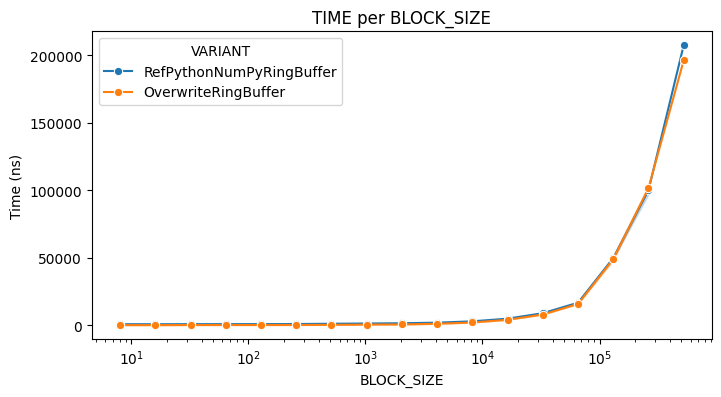


df_32


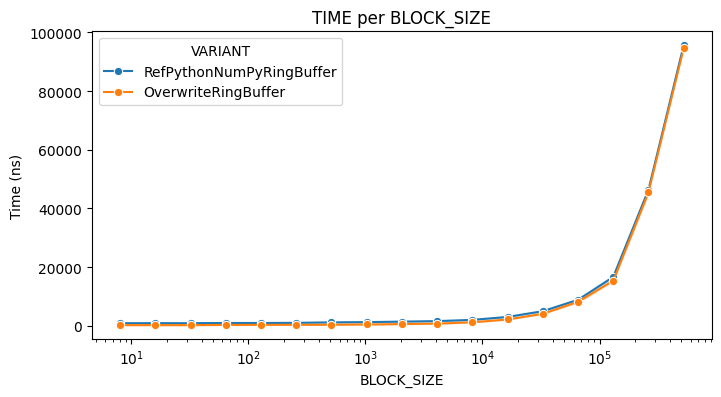

In [20]:
for name, df in df_dict.items():
    print(f"\n{name}")
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=df, x="BLOCK_SIZE", y="TIME", hue="VARIANT", marker="o")
    plt.xlabel("BLOCK_SIZE")
    plt.ylabel("Time (ns)")
    plt.title("TIME per BLOCK_SIZE")
    plt.xscale("log")
    plt.show()
    plt.close()


df_64


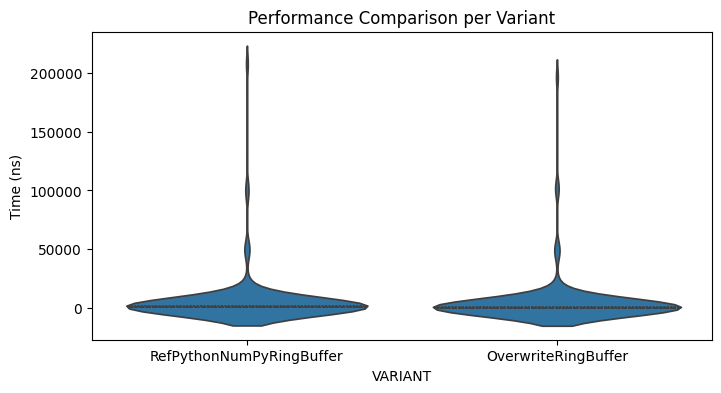


df_32


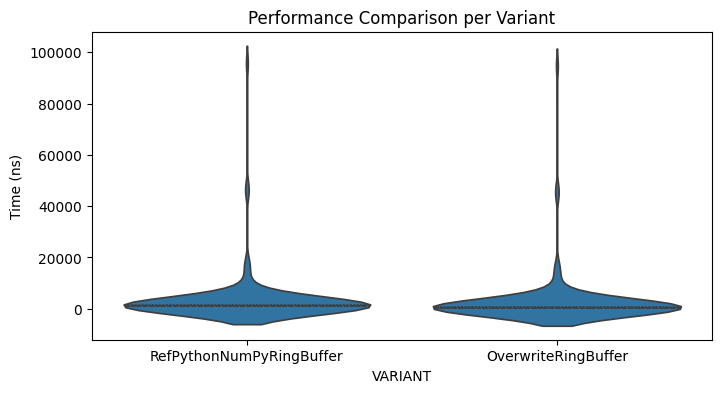

In [21]:
for name, df in df_dict.items():
    print(f"\n{name}")
    plt.figure(figsize=(8,4))
    sns.violinplot(data=df, x='VARIANT', y='TIME', inner="quartile")
    plt.ylabel("Time (ns)")
    plt.title("Performance Comparison per Variant")
    plt.show()
    plt.close()



df_64

--- BLOCK_SIZE ---

min rel = 0.985 at BLOCK_SIZE = 262_144
max rel = 3.681 at BLOCK_SIZE = 8
First diminishing performance below 1.05x at BLOCK_SIZE ≈ 76_822, rel = 1.050


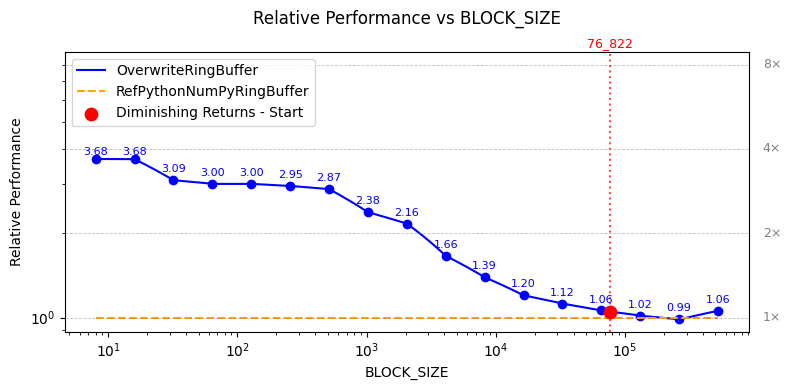



df_32

--- BLOCK_SIZE ---

min rel = 1.011 at BLOCK_SIZE = 524_288
max rel = 3.833 at BLOCK_SIZE = 8
First diminishing performance below 1.05x at BLOCK_SIZE ≈ 190_911, rel = 1.049


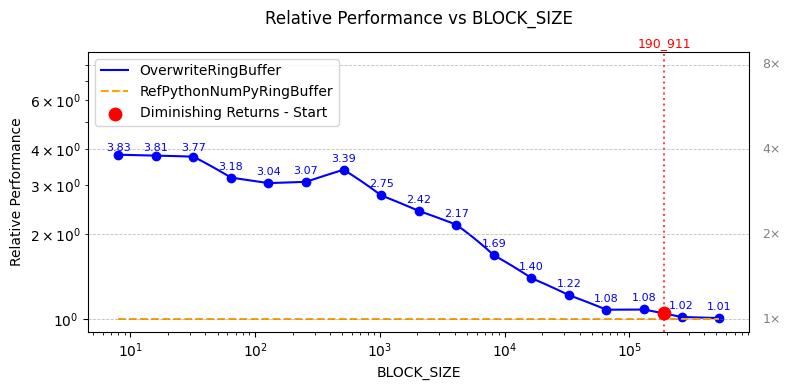

In [27]:
METRICS = [
    "BLOCK_SIZE",
]

for name, df in df_dict.items():
    print(f"\n\n{name}")

    df_pivot = df.pivot(
        index=["BLOCK_SIZE", "MAX_LEN", "NUM_RUNS"],
        columns="VARIANT",
        values="TIME",
    ).reset_index()

    for metric in METRICS:
        df_grouped = df_pivot.groupby(metric).mean().reset_index()
        df_grouped = df_grouped.sort_values(metric)
        df_grouped["rel"] = (
            df_grouped["RefPythonNumPyRingBuffer"]
            / df_grouped["OverwriteRingBuffer"]
        )

        min_idx = df_grouped["rel"].idxmin()
        max_idx = df_grouped["rel"].idxmax()

        min_val = df_grouped.loc[min_idx, "rel"]
        max_val = df_grouped.loc[max_idx, "rel"]

        min_x = df_grouped.loc[min_idx, metric]
        max_x = df_grouped.loc[max_idx, metric]

        print(f"\n--- {metric} ---\n")
        print(f"min rel = {min_val:.3f} at {metric} = {min_x:_}")
        print(f"max rel = {max_val:.3f} at {metric} = {max_x:_}")

        x = df_grouped[metric].values
        y_numpy = df_grouped["rel"].values

        x_smooth = np.logspace(np.log10(x.min()), np.log10(x.max()), 1000)
        y_numpy_smooth = np.interp(np.log10(x_smooth), np.log10(x), y_numpy)

        # Find first diminishing performance point < 1.05, left to right
        first_diminish_idx = np.where(y_numpy_smooth < 1.05)[0]
        if first_diminish_idx.size > 0:
            idx = first_diminish_idx[0]
            x_diminish = x_smooth[idx]
            y_diminish = y_numpy_smooth[idx]
            print(
                f"First diminishing performance below 1.05x at {metric} ≈ {round(x_diminish):_}, rel = {y_diminish:.3f}"
            )
        else:
            x_diminish = None
            print(f"Performance never drops below 1.05 for {metric}")

        fig, ax = plt.subplots(figsize=(8, 4))

        ax.plot(
            x_smooth, y_numpy_smooth, label="OverwriteRingBuffer", color="blue"
        )
        ax.scatter(x, y_numpy, color="blue")
        ymax = ax.get_ylim()[1]
        for xi, yi in zip(x, y_numpy):
            y_text = min(yi * 1.05, ymax * 0.98)
            ax.text(
                xi,
                y_text,
                f"{yi:.2f}",
                fontsize=8,
                ha="center",
                va="bottom",
                color="blue",
            )

        ax.plot(
            x_smooth,
            np.ones_like(x_smooth),
            label="RefPythonNumPyRingBuffer",
            color="orange",
            linestyle="--",
        )

        if x_diminish is not None:
            ax.scatter(
                x_diminish,
                y_diminish,
                color="red",
                s=80,
                zorder=5,
                label="Diminishing Returns - Start",
            )
            ax.axvline(x_diminish, color='red', linestyle=':', alpha=0.7)
            ax.text(x_diminish, y_diminish*0.97, f"{round(x_diminish):_}", color='red', fontsize=9,
                    ha='center', transform=ax.get_xaxis_transform())

        ref_lines = [1, 2, 4, 8]
        for r in ref_lines:
            ax.axhline(
                r, color="gray", linestyle="--", linewidth=0.6, alpha=0.5
            )
            ax.text(
                1.02,
                r,
                f"{r}×",
                va="center",
                ha="left",
                color="gray",
                fontsize=9,
                transform=ax.get_yaxis_transform(),
            )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(metric)
        ax.set_ylabel("Relative Performance")
        ax.set_title(f"Relative Performance vs {metric}", pad=20)
        ax.legend(loc="upper left")
        plt.tight_layout()
        plt.show()

        filename = os.path.join(plot_dir, f"{name}_{metric}.png")
        fig.savefig(filename, dpi=300)
        plt.close()